# Predicting NBA Game Outcomes Using Historical Team Performance Data

**CIS 5450: Big Data Analytics — Final Project**

Michel Faloughi, Sejal Kotian, Jaime Mizrachi, Aditya Jithesh

Spring 2026, University of Pennsylvania

## 1. Introduction & Background

### The Problem

Can we predict whether an NBA team will win a game using only information available *before tip-off*?

This is a binary classification problem: given two teams about to play, we predict `Win` or `Loss` for each team based on their historical performance, schedule context, and opponent strength. Crucially, we cannot use the current game's box score stats (points scored, shooting percentages, rebounds, etc.) as input features, since those are only known *after* the game is played. Using them would be data leakage.

### Why This Matters

Game outcome prediction sits at the intersection of sports analytics, media, and the multi-billion-dollar sports betting industry. Accurate pre-game models are valuable to:

- **Sports analysts and front offices** evaluating team strength and matchup quality
- **Broadcast and media companies** framing game narratives and setting expectations
- **Bettors and market makers** calibrating odds and identifying value

Beyond the applied value, the NBA provides an ideal testbed for data science methods: games produce rich structured statistics and seasons have clear temporal ordering.

Also, we're all NBA fans (go sixers! 😄) and thought it would be a cool topic to build our cis 545 project around ! xD

### Notebook Structure

| Section | Description |
|---|---|
| 1. Introduction & Background | Problem definition, motivation, dataset overview |
| 2. Data Acquisition | Downloading and storing raw data from the NBA API |
| 3. Exploratory Data Analysis | Distributions, trends, hypothesis testing |
| 4. Data Cleaning & Feature Engineering | Leakage-safe feature construction |
| 5. Modeling & Evaluation | Baseline, LR, RF, XGBoost, tuning, comparison |
| 6. Challenges & Obstacles | Difficulties encountered during the project |
| 7. Next Steps & Future Work | Directions for improvement |

## 2. Data Acquisition

### Our Approach

We collect 25 seasons of NBA data (2000-01 through 2024-25), covering over 60,000 team-game observations. From raw box scores, we engineer pre-game features: shifted rolling averages, season-to-date metrics, prior-season team quality priors, rest and schedule context, and opponent-adjusted matchup features. All of these are designed to capture what is knowable before the game starts.

We then train and compare four models (Logistic Regression, Random Forest, XGBoost, and a hyperparameter-tuned XGBoost) using a strict time-aware train/test split (train on 2001-2020, test on 2020-2025) to avoid temporal leakage.

### Data Source

Our primary data source is the `nba_api` Python package ([github.com/swar/nba_api](https://github.com/swar/nba_api)), which provides free, public access to the official NBA statistics hosted on `stats.nba.com`. No API key is required. All data is publicly available and legal.

We collected data spanning 25 NBA seasons (2000-01 through 2024-25) from three endpoints:

| Dataset | Endpoint | Rows | Description |
|---|---|---|---|
| Team Game Logs | `TeamGameLogs` | ~60,000 | Per-game box scores for every team, every season |
| Advanced Team Stats | `LeagueDashTeamStats` | ~750 | Season-level advanced metrics (net rating, pace, TS%) per team |
| League Game Finder | `LeagueGameFinder` | ~60,000 | Flat index of all game results, used for validation |

Each row in the game logs represents one team's performance in one game (both teams in a game get their own row). Over 25 seasons this produces ~60,000 team-game rows, comfortably exceeding the 50,000-row minimum.

### Rate Limiting

The NBA API enforces rate limits on `stats.nba.com`. Our download code uses `time.sleep(1.2)` between requests and includes retry logic (up to 3 attempts per request). A full fresh download takes 10-25 minutes. Since the raw data is committed to the repository, re-downloading is not necessary to run this notebook.

In [21]:
import os
import time
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from scipy import stats as scipy_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

# Paths
RAW_DIR = Path('data/raw')
GAME_LOG_DIR = RAW_DIR / 'game_logs'
TEAM_STATS_DIR = RAW_DIR / 'team_stats'
PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Season list: 2000-01 through 2024-25
def make_season_id(start_year: int) -> str:
    return f'{start_year}-{str(start_year + 1)[-2:]}'

SEASONS = [make_season_id(y) for y in range(2000, 2025)]

# Constants
RANDOM_STATE = 42
TRAIN_CUTOFF = 2020  # seasons before this year go to train, >= go to test

print(f'Seasons: {SEASONS[0]} through {SEASONS[-1]} ({len(SEASONS)} total)')
print('All imports successful.')

Seasons: 2000-01 through 2024-25 (25 total)
All imports successful.


### Download Team Game Logs

The `TeamGameLogs` endpoint provides per-game box score stats for every team in a given season. Key columns include points, shooting splits (FG/3P/FT), rebounds, assists, turnovers, steals, blocks, and plus/minus. We download one CSV per season and skip any files that already exist on disk.

In [22]:
from nba_api.stats.endpoints import TeamGameLogs

GAME_LOG_DIR.mkdir(parents=True, exist_ok=True)
all_game_logs = []

for season in SEASONS:
    out_path = GAME_LOG_DIR / f'game_logs_{season}.csv'

    if out_path.exists():
        df = pd.read_csv(out_path)
        all_game_logs.append(df)
        continue

    retries = 3
    for attempt in range(retries):
        try:
            logs = TeamGameLogs(
                season_nullable=season,
                season_type_nullable='Regular Season',
            )
            df = logs.get_data_frames()[0]
            df['SEASON'] = season
            df.to_csv(out_path, index=False)
            print(f'  [OK]   {season} — {len(df):,} rows saved')
            all_game_logs.append(df)
            break
        except Exception as e:
            if attempt < retries - 1:
                print(f'  [RETRY] {season} attempt {attempt + 1} failed: {e}')
                time.sleep(5)
            else:
                print(f'  [ERR]  {season} — {e}')
    time.sleep(1.2)

game_logs_all = pd.concat(all_game_logs, ignore_index=True)
print(f'\nGame logs loaded: {game_logs_all.shape[0]:,} rows x {game_logs_all.shape[1]} columns across {len(all_game_logs)} seasons')


Game logs loaded: 60,048 rows x 58 columns across 25 seasons


### Download Season-Level Advanced Team Stats

The `LeagueDashTeamStats` endpoint provides aggregated season-level metrics per team, including offensive rating, defensive rating, net rating, pace, and true shooting percentage. One row = one team's full-season summary.

In [23]:
from nba_api.stats.endpoints import LeagueDashTeamStats

TEAM_STATS_DIR.mkdir(parents=True, exist_ok=True)
all_team_stats = []

for season in SEASONS:
    out_path = TEAM_STATS_DIR / f'team_stats_{season}.csv'

    if out_path.exists():
        df = pd.read_csv(out_path)
        all_team_stats.append(df)
        continue

    retries = 3
    for attempt in range(retries):
        try:
            stats = LeagueDashTeamStats(
                season=season,
                season_type_all_star='Regular Season',
                measure_type_detailed_defense='Advanced',
            )
            df = stats.get_data_frames()[0]
            df['SEASON'] = season
            df.to_csv(out_path, index=False)
            print(f'  [OK]   {season} — {len(df):,} teams saved')
            all_team_stats.append(df)
            break
        except Exception as e:
            if attempt < retries - 1:
                print(f'  [RETRY] {season} attempt {attempt + 1} failed: {e}')
                time.sleep(5)
            else:
                print(f'  [ERR]  {season} — {e}')
    time.sleep(1.2)

team_stats_all = pd.concat(all_team_stats, ignore_index=True)
print(f'\nAdvanced team stats loaded: {team_stats_all.shape[0]:,} rows x {team_stats_all.shape[1]} columns across {len(all_team_stats)} seasons')


Advanced team stats loaded: 746 rows x 47 columns across 25 seasons


### Download League Game Finder

The `LeagueGameFinder` endpoint returns every NBA game result across all seasons. We use it as a validation source to cross-check the game logs. Downloaded season by season to respect rate limits.

In [24]:
from nba_api.stats.endpoints import LeagueGameFinder

lgf_path = RAW_DIR / 'league_game_finder.csv'

if lgf_path.exists():
    lgf_df = pd.read_csv(lgf_path)
    print(f'League game finder loaded from disk: {lgf_df.shape[0]:,} rows')
else:
    print('Downloading league game finder data (season by season)...')
    lgf_frames = []

    for season in SEASONS:
        retries = 3
        for attempt in range(retries):
            try:
                lgf = LeagueGameFinder(
                    season_nullable=season,
                    season_type_nullable='Regular Season',
                    league_id_nullable='00',
                )
                df = lgf.get_data_frames()[0]
                lgf_frames.append(df)
                print(f'  [OK]   {season} — {len(df):,} rows')
                break
            except Exception as e:
                if attempt < retries - 1:
                    print(f'  [RETRY] {season} attempt {attempt + 1} failed: {e}')
                    time.sleep(5)
                else:
                    print(f'  [ERR]  {season} — {e}')
        time.sleep(1.2)

    lgf_df = pd.concat(lgf_frames, ignore_index=True)
    lgf_df['SEASON_YEAR'] = lgf_df['SEASON_ID'].astype(str).str[1:].astype(int)
    lgf_df = lgf_df[lgf_df['SEASON_YEAR'] >= 2000].copy()
    lgf_df.to_csv(lgf_path, index=False)
    print(f'Saved {len(lgf_df):,} rows to {lgf_path.name}')

League game finder loaded from disk: 60,048 rows


### Acquisition Summary

A quick check that all expected files are present and the row counts match expectations.

In [25]:
# Completeness checks
expected_game_log_files = {f'game_logs_{s}.csv' for s in SEASONS}
actual_game_log_files = {f.name for f in GAME_LOG_DIR.glob('*.csv')}
missing_gl = expected_game_log_files - actual_game_log_files

expected_ts_files = {f'team_stats_{s}.csv' for s in SEASONS}
actual_ts_files = {f.name for f in TEAM_STATS_DIR.glob('*.csv')}
missing_ts = expected_ts_files - actual_ts_files

print('=== Acquisition Summary ===')
print(f'  Game logs      : {game_logs_all.shape[0]:>8,} rows across {len(actual_game_log_files)} season files')
print(f'  Team stats     : {team_stats_all.shape[0]:>8,} rows across {len(actual_ts_files)} season files')
print(f'  League finder  : {lgf_df.shape[0]:>8,} rows')
print()
print(f'  Missing game log files : {sorted(missing_gl) if missing_gl else "None"}')
print(f'  Missing team stat files: {sorted(missing_ts) if missing_ts else "None"}')
print(f'  league_game_finder.csv : {"Present" if lgf_path.exists() else "MISSING"}')

=== Acquisition Summary ===
  Game logs      :   60,048 rows across 25 season files
  Team stats     :      746 rows across 25 season files
  League finder  :   60,048 rows

  Missing game log files : None
  Missing team stat files: None
  league_game_finder.csv : Present


### Initial Data Inspection

Before any feature engineering, we inspect the raw data to understand its structure, check for missing values, and confirm the data types are what we expect.

In [26]:
# Shape and column overview
print('=== Game Logs ===')
print(f'Shape: {game_logs_all.shape}')
print(f'Columns: {list(game_logs_all.columns)}\n')

print('=== Advanced Team Stats ===')
print(f'Shape: {team_stats_all.shape}')
print(f'Columns: {list(team_stats_all.columns)}\n')

print('=== League Game Finder ===')
print(f'Shape: {lgf_df.shape}')
print(f'Columns: {list(lgf_df.columns)}')

=== Game Logs ===
Shape: (60048, 58)
Columns: ['SEASON_YEAR', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'AVAILABLE_FLAG', 'SEASON']

=== Advanced Team Stats ===
Shape: (746, 47)
Columns: ['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PA

In [27]:
# Preview the game logs (our primary dataset)
game_logs_all.head()

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG,SEASON
0,2000-01,1610612760,SEA,Seattle SuperSonics,20001189,2001-04-18T00:00:00,SEA vs. SAS,W,48.0000,43,85,0.5060,8,13,0.6150,11,15,0.7330,9,41,50,26,5.0000,6,8,8,14,0,105,38.0000,1,1,1,1,167,143,585,364,214,1137,72,2089,2127,1366,1717,43,259,431,4,1563,300,1909,45,160,418,3,NaN,2000-01
1,2000-01,1610612742,DAL,Dallas Mavericks,20001185,2001-04-18T00:00:00,DAL vs. MIN,W,48.0000,50,91,0.5490,5,17,0.2940,15,20,0.7500,6,39,45,33,14.0000,8,9,2,23,2,120,20.0000,1,1,1,1,167,6,185,91,864,498,1559,1610,1666,1153,2203,120,747,28,872,910,175,162,1253,1,34,136,NaN,2000-01
2,2000-01,1610612763,VAN,Vancouver Grizzlies,20001188,2001-04-18T00:00:00,VAN @ GSW,W,48.0000,37,92,0.4020,4,9,0.4440,17,21,0.8100,27,31,58,18,14.0000,9,10,10,21,0,95,14.0000,1,1,1,1,167,839,146,1831,1234,1891,549,1280,1553,669,5,995,30,1723,872,652,103,2205,849,160,1142,285,NaN,2000-01
3,2000-01,1610612748,MIA,Miami Heat,20001183,2001-04-18T00:00:00,MIA @ ORL,W,48.0000,43,89,0.4830,2,10,0.2000,15,23,0.6520,19,32,51,33,14.0000,10,5,7,17,1,103,12.0000,1,1,1,1,167,143,288,578,1939,1709,2013,1610,1318,1983,108,825,202,28,872,418,1027,1674,233,9,534,371,NaN,2000-01
4,2000-01,1610612743,DEN,Denver Nuggets,20001186,2001-04-18T00:00:00,DEN vs. SAC,W,48.0000,46,108,0.4260,11,21,0.5240,7,8,0.8750,27,37,64,33,19.0000,10,6,4,18,0,110,10.0000,1,1,1,1,167,40,2,1471,33,169,244,2316,2358,223,5,221,3,28,1920,418,706,688,345,160,201,486,NaN,2000-01


In [28]:
# Check for missing values across all three datasets
missing_summary = pd.DataFrame([
    {'Dataset': 'Game Logs', 'Total Cells': game_logs_all.size, 'Missing': game_logs_all.isna().sum().sum(),
     'Pct Missing': f'{game_logs_all.isna().sum().sum() / game_logs_all.size:.2%}'},
    {'Dataset': 'Team Stats', 'Total Cells': team_stats_all.size, 'Missing': team_stats_all.isna().sum().sum(),
     'Pct Missing': f'{team_stats_all.isna().sum().sum() / team_stats_all.size:.2%}'},
    {'Dataset': 'League Game Finder', 'Total Cells': lgf_df.size, 'Missing': lgf_df.isna().sum().sum(),
     'Pct Missing': f'{lgf_df.isna().sum().sum() / lgf_df.size:.2%}'},
])
display(missing_summary)

# Which columns have missing values?
print('\nColumns with missing values in game logs:')
gl_missing = game_logs_all.isna().sum()
print(gl_missing[gl_missing > 0].to_string())

,Dataset,Total Cells,Missing,Pct Missing
0,Game Logs,3482784,28726,0.82%
1,Team Stats,35062,0,0.00%
2,League Game Finder,1741392,1,0.00%



Columns with missing values in game logs:
AVAILABLE_FLAG    28726


### Initial Cleaning

Before moving to EDA, we apply light cleaning to make the dataframes ready for exploration: drop endpoint metadata columns, parse dates into proper datetime types, derive the binary target (`is_win`) and home/away indicator (`is_home`), and run integrity checks. EDA needs these basic columns to compute things like home win rate or stat differences between winners and losers.

The bulk of feature engineering (rolling windows, opponent joins, matchup differences, prior-season priors) happens in Section 4 after EDA has informed which feature families are worth building.

#### Dropping Unnecessary Columns

The game logs contain 27 `_RANK` columns and an `AVAILABLE_FLAG` column that are endpoint metadata rather than meaningful basketball statistics. We drop these now to keep the dataset focused on actual performance data.

In [29]:
# Identify and drop rank/metadata columns from game logs
rank_columns = [col for col in game_logs_all.columns if col.endswith('_RANK')]
metadata_to_drop = ['AVAILABLE_FLAG'] + rank_columns
print(f'Dropping {len(metadata_to_drop)} columns: {len(rank_columns)} rank columns + AVAILABLE_FLAG')

game_logs_clean = game_logs_all.drop(columns=metadata_to_drop, errors='ignore')

# Similarly clean team stats
team_rank_columns = [col for col in team_stats_all.columns if col.endswith('_RANK')]
team_stats_clean = team_stats_all.drop(columns=team_rank_columns, errors='ignore')

print(f'\nGame logs: {game_logs_all.shape[1]} columns -> {game_logs_clean.shape[1]} columns')
print(f'Team stats: {team_stats_all.shape[1]} columns -> {team_stats_clean.shape[1]} columns')

Dropping 27 columns: 26 rank columns + AVAILABLE_FLAG

Game logs: 58 columns -> 31 columns
Team stats: 47 columns -> 28 columns


#### Standardizing Fields and Deriving Helper Columns

We parse dates, create a binary target (`is_win`), extract home/away status from the matchup string, identify the opponent, and flag the small number of neutral-site games where home/away cannot be determined.

In [30]:
# Build a season ordering lookup for consistent sorting
season_order_lookup = pd.Series(
    data=range(1, game_logs_clean['SEASON_YEAR'].nunique() + 1),
    index=sorted(game_logs_clean['SEASON_YEAR'].unique()),
)

game_logs_clean = (
    game_logs_clean
    .assign(
        GAME_DATE=lambda df: pd.to_datetime(df['GAME_DATE'], errors='raise').dt.normalize(),
        is_win=lambda df: df['WL'].map({'W': 1, 'L': 0}).astype('int8'),
        is_home=lambda df: df['MATCHUP'].str.contains(' vs. ', regex=False).astype('int8'),
        opponent_abbr=lambda df: df['MATCHUP'].str.extract(r'(?:vs\.|@)\s+([A-Z]{2,3})', expand=False),
        season_start_year=lambda df: df['SEASON_YEAR'].str.slice(0, 4).astype('int16'),
        game_month=lambda df: df['GAME_DATE'].dt.month.astype('int8'),
        game_year=lambda df: df['GAME_DATE'].dt.year.astype('int16'),
        season_order=lambda df: df['SEASON_YEAR'].map(season_order_lookup).astype('int16'),
    )
)

# Flag neutral-site or unresolved home/away games
# (a normal game has exactly 1 home team; if a GAME_ID has 0 or 2, something is off)
home_counts = game_logs_clean.groupby('GAME_ID')['is_home'].sum()
neutral_ids = home_counts.loc[home_counts.ne(1)].index
game_logs_clean['is_neutral_or_unresolved'] = game_logs_clean['GAME_ID'].isin(neutral_ids).astype('int8')

# Add season info to team stats too
team_stats_clean = team_stats_clean.assign(
    season_start_year=lambda df: df['SEASON'].str.slice(0, 4).astype('int16'),
    season_order=lambda df: df['SEASON'].map(season_order_lookup).astype('Int16'),
)

print(f'Derived columns added. Final game logs shape: {game_logs_clean.shape}')
print(f'Neutral/unresolved games: {len(neutral_ids)}')
print(f'Win/Loss distribution:\n{game_logs_clean["WL"].value_counts().to_string()}')

Derived columns added. Final game logs shape: (60048, 39)
Neutral/unresolved games: 5
Win/Loss distribution:
WL
W    30024
L    30024


#### Data Integrity Checks

Before moving to EDA, we verify the core assumptions: no duplicate rows, exactly two team rows per game, and no unexpected nulls in the cleaned data.

All 60,048 rows survive Part 2. We don't drop any rows here because there are no null targets, no duplicates, and the 5 neutral-site games are flagged (via `is_neutral_or_unresolved`) rather than removed. Row reduction happens later in Section 4, where the first-collected season (no prior-season advanced stats available) and season-opener rows (no prior-game rolling history yet) are filtered out of the model-ready table. Those are informed drops based on which features can be computed, not generic data-quality cleanup.

In [31]:
# Integrity checks
assert not game_logs_clean.duplicated(['GAME_ID', 'TEAM_ID']).any(), 'Duplicate GAME_ID + TEAM_ID rows found'
assert game_logs_clean.groupby('GAME_ID').size().eq(2).all(), 'Not all games have exactly 2 team rows'
assert set(game_logs_clean['WL'].unique()) == {'W', 'L'}, 'Unexpected WL values'

unexpected_nulls = game_logs_clean.isna().sum().loc[lambda c: c > 0]
print('Unexpected nulls after cleaning:')
if unexpected_nulls.empty:
    print('  None')
else:
    print(unexpected_nulls.to_string())

print(f'\nAll integrity checks passed.')
print(f'  {game_logs_clean.shape[0]:,} team-game rows')
print(f'  {game_logs_clean["GAME_ID"].nunique():,} unique games')
print(f'  {game_logs_clean["SEASON_YEAR"].nunique()} seasons')
print(f'  {game_logs_clean["TEAM_ID"].nunique()} teams')

Unexpected nulls after cleaning:
  None

All integrity checks passed.
  60,048 team-game rows
  30,024 unique games
  25 seasons
  30 teams


## 3. Exploratory Data Analysis

With the data acquired and lightly cleaned, we now explore it to understand what we're working with and what predictive signals exist. This section has two parts:

1. **Visual EDA** (3.1 - 3.5): coverage, target balance, league trends, winner-vs-loser differences, and team quality.
2. **Hypothesis testing** (3.6): four families of formal tests including the two simulation-based tests promised in the proposal (home court advantage, rest day effect).

A central reminder threads through the whole section: same-game stats like `PTS`, `PLUS_MINUS`, `FG_PCT`, `REB`, `AST`, and `TOV` are descriptive of *why* a team won, but they are **not usable as direct model features** because they are post-tip-off observations. The EDA uses them to surface patterns; Section 4 then converts those patterns into shifted rolling, season-to-date, prior-season, and matchup-difference features that respect the leakage rule.

### 3.1 Coverage, Target Balance, and Home Court

We start by confirming what we have: how many games per season, how the target is distributed, and how often home teams win. The target is balanced 50/50 by construction (each game produces one winner row and one loser row), so the home win rate is the more interesting starting point.

In [32]:
# Build per-season summary table and the home/non-home split used throughout EDA
non_neutral_games = game_logs_clean.loc[game_logs_clean['is_neutral_or_unresolved'] == 0].copy()
home_rows = non_neutral_games.loc[non_neutral_games['is_home'] == 1].copy()

season_summary = (
    game_logs_clean
    .groupby('SEASON_YEAR')
    .agg(
        rows=('GAME_ID', 'size'),
        games=('GAME_ID', 'nunique'),
        teams=('TEAM_ID', 'nunique'),
        avg_points=('PTS', 'mean'),
        avg_fg_pct=('FG_PCT', 'mean'),
        avg_fg3a=('FG3A', 'mean'),
        avg_fg3_pct=('FG3_PCT', 'mean'),
        avg_turnovers=('TOV', 'mean'),
    )
    .reset_index()
)

season_home_summary = (
    home_rows
    .groupby('SEASON_YEAR')
    .agg(home_games=('GAME_ID', 'nunique'), home_wins=('is_win', 'sum'))
    .assign(home_win_rate=lambda frame: frame['home_wins'] / frame['home_games'])
    .reset_index()
)

season_team_summary = (
    team_stats_clean
    .groupby('SEASON')
    .agg(
        avg_pace=('PACE', 'mean'),
        avg_off_rating=('OFF_RATING', 'mean'),
        avg_def_rating=('DEF_RATING', 'mean'),
        avg_net_rating=('NET_RATING', 'mean'),
        avg_ts_pct=('TS_PCT', 'mean'),
    )
    .reset_index()
    .rename(columns={'SEASON': 'SEASON_YEAR'})
)

season_summary = (
    season_summary
    .merge(season_home_summary, on='SEASON_YEAR', how='left')
    .merge(season_team_summary, on='SEASON_YEAR', how='left')
)

target_balance = (
    game_logs_clean['WL']
    .value_counts()
    .rename_axis('WL')
    .reset_index(name='rows')
    .assign(share=lambda frame: frame['rows'] / frame['rows'].sum())
)

display(target_balance)
display(season_summary[['SEASON_YEAR', 'games', 'teams', 'avg_points', 'avg_fg3a', 'home_win_rate']].head())
display(season_summary[['SEASON_YEAR', 'games', 'teams', 'avg_points', 'avg_fg3a', 'home_win_rate']].tail())

,WL,rows,share
0,W,30024,0.5000
1,L,30024,0.5000


,SEASON_YEAR,games,teams,avg_points,avg_fg3a,home_win_rate
0,2000-01,1189,29,94.8103,13.7077,0.5980
1,2001-02,1189,29,95.4765,14.7494,0.5913
2,2002-03,1189,29,95.0807,14.6817,0.6283
3,2003-04,1189,29,93.3978,14.9256,0.6140
4,2004-05,1230,30,97.1988,15.7512,0.6049


,SEASON_YEAR,games,teams,avg_points,avg_fg3a,home_win_rate
20,2020-21,1080,30,112.0912,34.6398,0.5435
21,2021-22,1230,30,110.6159,35.1768,0.5439
22,2022-23,1230,30,114.6858,34.2130,0.5805
23,2023-24,1230,30,114.2114,35.1037,0.5431
24,2024-25,1230,30,113.8252,37.5829,0.5445


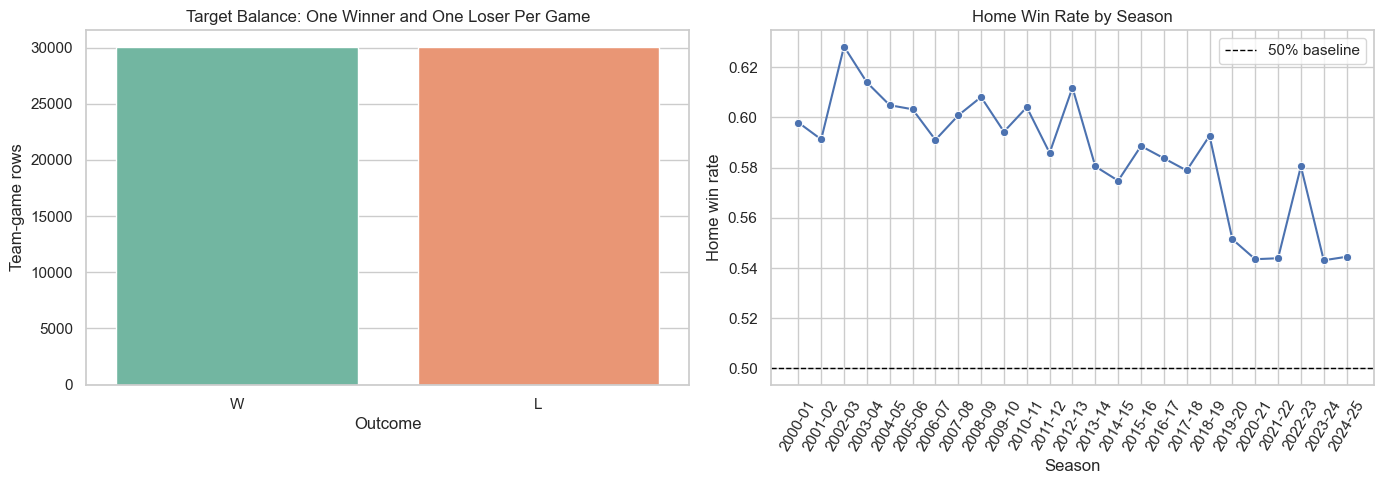

In [33]:
# Two-panel chart: target balance bar chart and home win rate trend by season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=target_balance, x='WL', y='rows', hue='WL', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Target Balance: One Winner and One Loser Per Game')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Team-game rows')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='home_win_rate', marker='o', ax=axes[1])
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% baseline')
axes[1].set_title('Home Win Rate by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Home win rate')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend()

plt.tight_layout()
plt.show()

An interactive plotly version of the home win rate chart for hover-over inspection (requires `pip install plotly`):

In [ ]:
# Interactive plotly version of the home win rate trend (hover for exact values)
import plotly.express as px

plotly_fig = px.line(
    season_summary,
    x='SEASON_YEAR',
    y='home_win_rate',
    markers=True,
    title='Home Win Rate by Season (interactive)',
    labels={'home_win_rate': 'Home win rate', 'SEASON_YEAR': 'Season'},
)
plotly_fig.add_hline(y=0.5, line_dash='dash', line_color='black',
                     annotation_text='50% baseline')
plotly_fig.update_layout(yaxis_tickformat='.1%', height=420)
plotly_fig.show()

**Takeaway.** Target is exactly 50/50 because each game contributes one win row and one loss row. Home win rate is well above 50% across all 25 seasons but is clearly trending downward (around 60% in the early 2000s, around 55% in the most recent seasons). Home court is therefore a strong candidate pre-game feature for Section 4, but its predictive power is era-dependent and should not be over-relied upon.

### 3.2 Era Effects: League Trends Over Time

Raw counting stats are not directly comparable across eras. The 3-point revolution, pace increases, and rule changes between 2000 and 2025 mean that a 110-point game in 2003 has a very different meaning than a 110-point game in 2024. We chart four key league-level metrics over time to see how much drift has occurred.

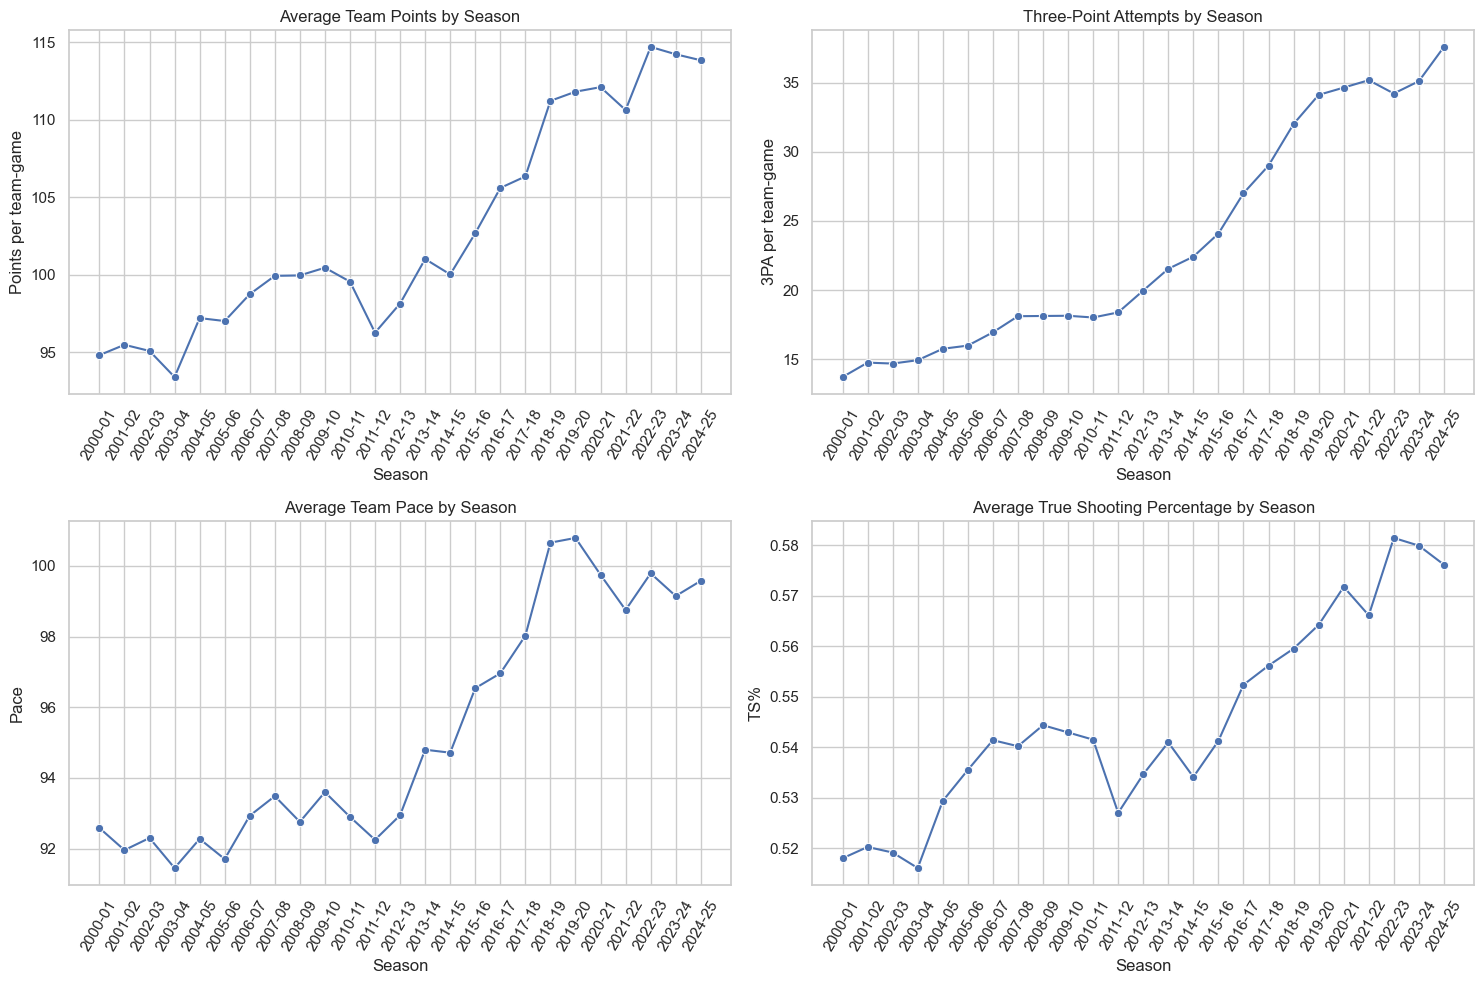

In [34]:
# Four-panel chart of league-level trends across 25 seasons
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_points', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Average Team Points by Season')
axes[0, 0].set_ylabel('Points per team-game')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_fg3a', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Three-Point Attempts by Season')
axes[0, 1].set_ylabel('3PA per team-game')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_pace', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Average Team Pace by Season')
axes[1, 0].set_ylabel('Pace')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_ts_pct', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Average True Shooting Percentage by Season')
axes[1, 1].set_ylabel('TS%')

for axis in axes.flatten():
    axis.set_xlabel('Season')
    axis.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

**Takeaway.** All four metrics drift meaningfully across the 25-year window. Points, 3-point attempts, pace, and true shooting all rise notably. This has two implications for modeling:

1. **Raw counting stats need normalization.** A "scoring 110" feature is not era-comparable, so Section 4 prefers ratios (offensive rating, true shooting %) and within-season relative measures (rolling averages within team-season).
2. **Time-aware validation is required.** Standard k-fold cross-validation would mix early-2000s games into validation folds for predicting 2024 games, which is not a realistic prediction setup. Section 5 will train on earlier seasons and test on more recent seasons to mirror real deployment.

### 3.3 Winner vs. Loser Differences

For each game, the winner and loser team rows differ on every box-score column. Quantifying the average difference tells us which stats are most associated with winning. The leakage caveat applies in full: these are post-game observations, so we cannot use them as direct features. We instead use the pattern as a *map* for which feature families to engineer (recent shooting, recent rebounding, recent ball security, etc.) in Section 4.

WL,Loser average,Winner average,winner_minus_loser
PLUS_MINUS,-11.1904,11.1904,22.3809
PTS,97.2053,108.3958,11.1904
REB,41.0946,44.5330,3.4384
AST,21.0387,24.3539,3.3152
BLK,4.4721,5.3098,0.8377
STL,7.2023,8.0029,0.8006
FG3_PCT,0.3217,0.3873,0.0657
FG_PCT,0.4322,0.4822,0.0500
FT_PCT,0.7521,0.7729,0.0208
TOV,14.7946,13.9215,-0.8731


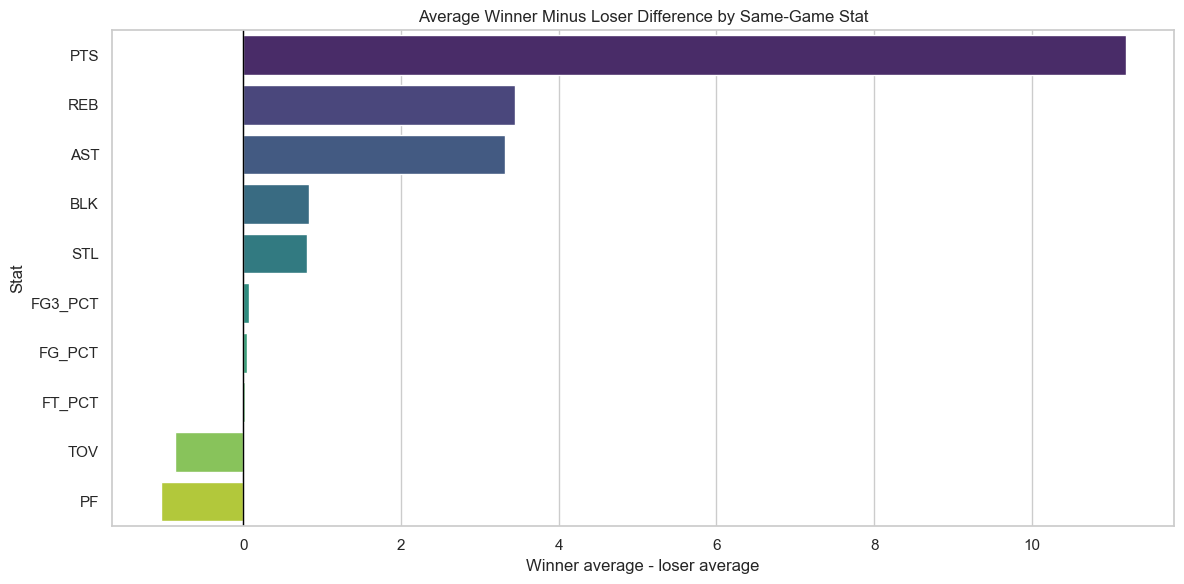

In [35]:
# Build the winner vs loser comparison table and visualize the differences
winner_loser_stats = ['PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS']

winner_loser_summary = (
    game_logs_clean
    .groupby('WL')[winner_loser_stats]
    .mean()
    .rename(index={'W': 'Winner average', 'L': 'Loser average'})
    .transpose()
    .assign(winner_minus_loser=lambda frame: frame['Winner average'] - frame['Loser average'])
    .sort_values('winner_minus_loser', ascending=False)
)

display(winner_loser_summary)

plot_diffs = (
    winner_loser_summary
    .drop(index=['PLUS_MINUS'])
    .reset_index(names='stat')
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_diffs, x='winner_minus_loser', y='stat', hue='stat', palette='viridis', legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Average Winner Minus Loser Difference by Same-Game Stat')
plt.xlabel('Winner average - loser average')
plt.ylabel('Stat')
plt.tight_layout()
plt.show()

**Takeaway.** Winners outscore losers by ~11 points on average and shoot meaningfully better from the field, three-point line, and free-throw line. They also out-rebound, out-assist, and turn the ball over less. The pattern is exactly the basketball intuition: winning is about efficient shot creation, ball security, possession control, and defensive disruption.

Section 4 will convert each of these signals into pre-game features by sorting each team's games chronologically, computing rolling averages over the last 5/10/20 games, and **shifting** the result so the current game's outcome is excluded from its own predictors. That way the model learns "this team has been shooting well lately" rather than "this team shot well in the very game we're trying to predict".

### 3.4 Same-Game Correlations with Outcome

A correlation heatmap of box-score columns against `is_win` reinforces the winner-vs-loser table and shows which signal categories cluster together (e.g., shooting percentages move with `is_win`; turnovers move against). Same leakage caveat: this is a *feature-design map*, not a feature list.

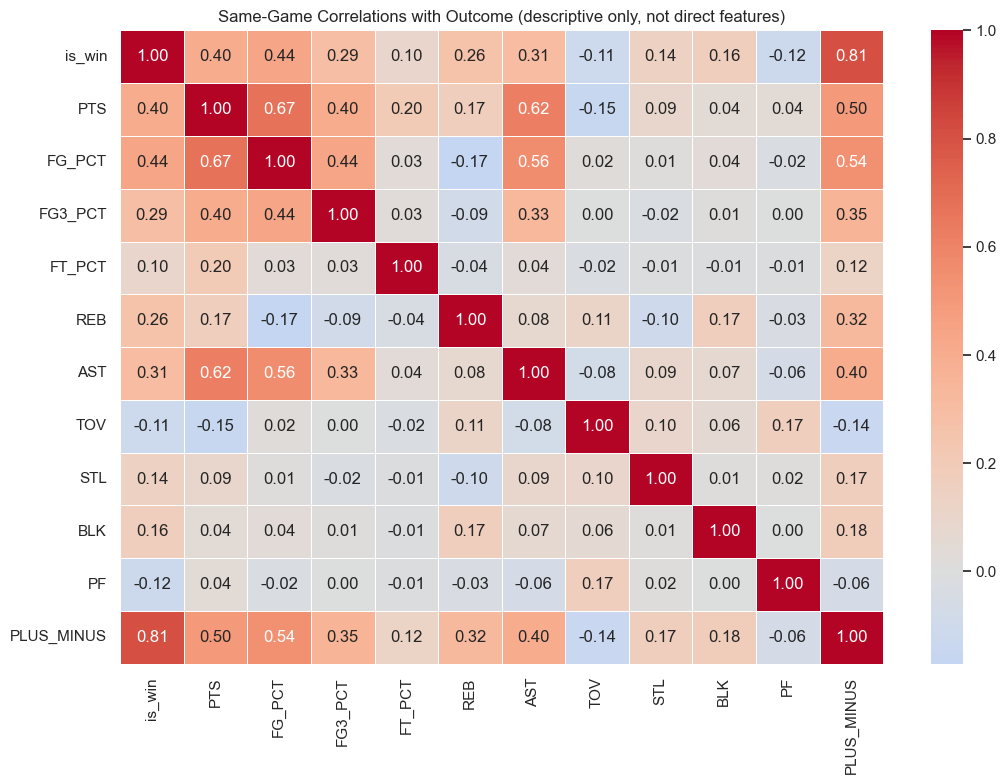

,corr_with_is_win
PLUS_MINUS,0.8071
FG_PCT,0.4437
PTS,0.4022
AST,0.3097
FG3_PCT,0.2946
REB,0.2603
BLK,0.1634
STL,0.1373
PF,-0.1176
TOV,-0.1108


In [36]:
# Correlation heatmap of same-game stats with outcome
same_game_corr_columns = ['is_win', 'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS']
same_game_corr = game_logs_clean[same_game_corr_columns].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(same_game_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Same-Game Correlations with Outcome (descriptive only, not direct features)')
plt.tight_layout()
plt.show()

display(
    same_game_corr['is_win']
    .drop('is_win')
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame('corr_with_is_win')
)

**Takeaway.** `PLUS_MINUS` correlates almost perfectly with `is_win` (it is literally the scoring margin). `PTS` and shooting percentages follow next. We translate these into recent scoring margin, recent shooting efficiency, recent rebounding, and recent turnover rate features, then add opponent-adjusted versions (team rolling offense minus opponent rolling defense) in Section 4.

### 3.5 Team Quality vs. Season Win %

The `team_stats` endpoint gives season-level advanced metrics (offensive rating, defensive rating, net rating, true shooting %, pace) for every team in every season. We expect strong teams to have better ratings, so we plot each metric against season win percentage to confirm and to gauge how strong each relationship is.

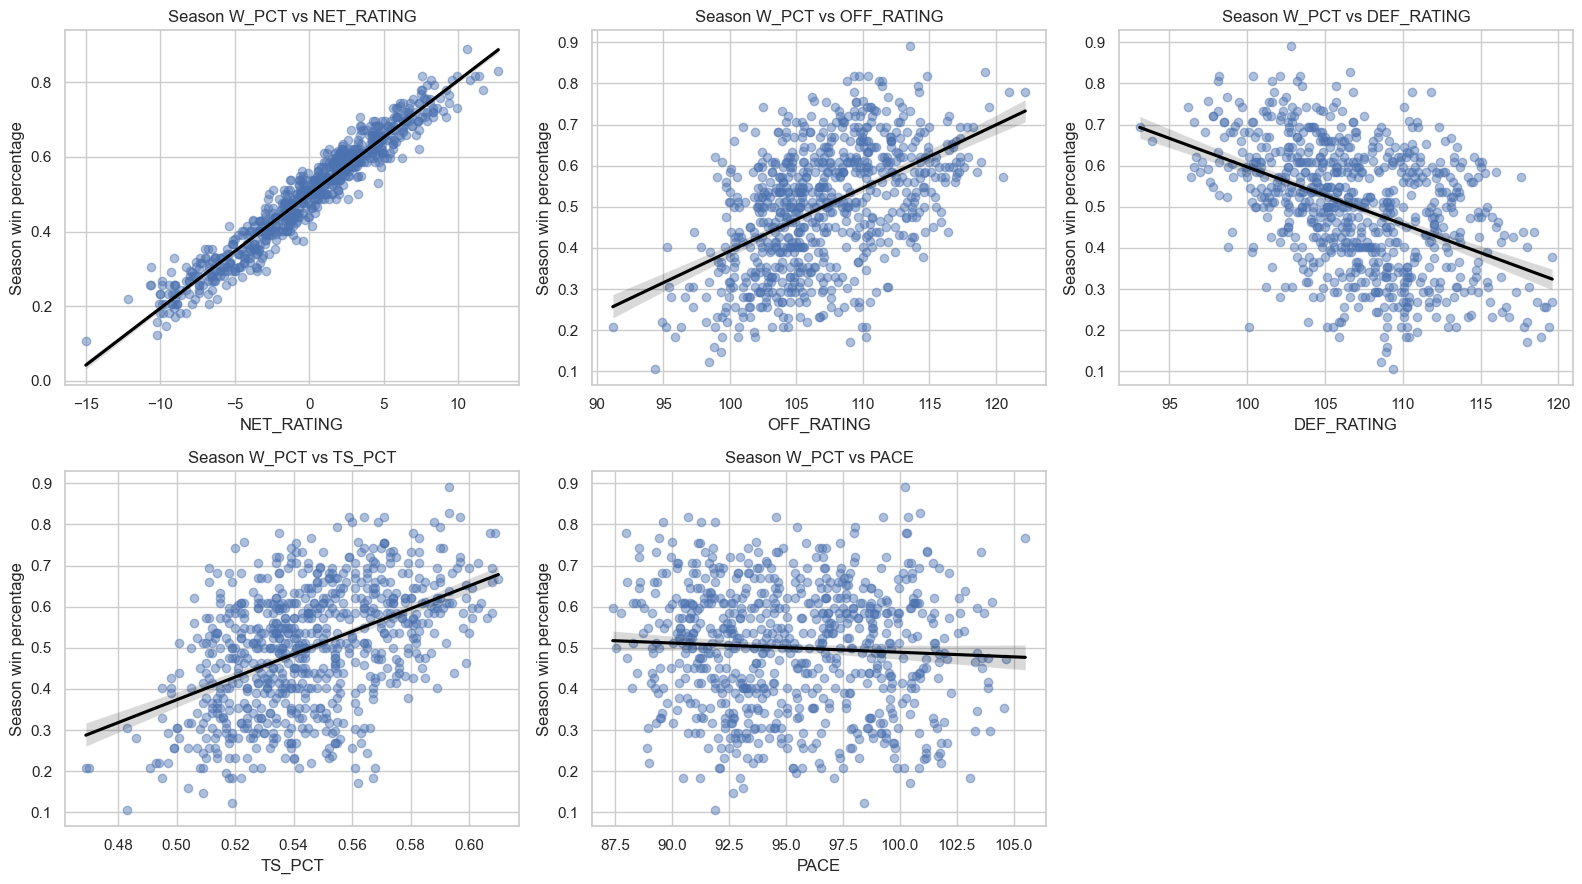

In [37]:
# Five-panel scatter regression plot: each advanced team metric vs. season W_PCT
team_strength_metrics = ['NET_RATING', 'OFF_RATING', 'DEF_RATING', 'TS_PCT', 'PACE']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_list = list(axes.flatten())

for metric, axis in zip(team_strength_metrics, axes_list):
    sns.regplot(
        data=team_stats_clean, x=metric, y='W_PCT',
        scatter_kws={'alpha': 0.45}, line_kws={'color': 'black'}, ax=axis,
    )
    axis.set_title(f'Season W_PCT vs {metric}')
    axis.set_xlabel(metric)
    axis.set_ylabel('Season win percentage')

axes_list[-1].axis('off')
plt.tight_layout()
plt.show()

**Takeaway.** Net rating tracks win % almost perfectly. Offensive rating, defensive rating, and true shooting all show clear (medium-strength) relationships. Pace alone barely moves with W%, confirming that playing fast is not the same as playing well.

**Leakage warning for these metrics.** A team's *final* season net rating cannot be used as a predictor for games inside that same season because the rating was computed using those very games. Section 4 uses **prior-season** values as starting priors for early-season games and shifted **rolling/season-to-date** values once enough games are in the books.

### 3.6 Outlier Check

Box-score stats span a wide range across 60,000 games. We look at the distributions of a few key columns to identify any genuine outliers and decide how to handle them. The summary statistics also satisfy the rubric expectation of inspecting variable distributions before modeling.

In [ ]:
# Distributions of key box-score and game-context variables to spot outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(data=game_logs_clean, x='PTS', bins=50, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Team points per game')
axes[0, 0].set_xlabel('PTS')

sns.histplot(data=game_logs_clean, x='TOV', bins=30, color='steelblue', ax=axes[0, 1])
axes[0, 1].set_title('Team turnovers per game')
axes[0, 1].set_xlabel('TOV')

sns.histplot(data=game_logs_clean, x='PLUS_MINUS', bins=60, color='steelblue', ax=axes[1, 0])
axes[1, 0].set_title('Plus/minus per game (final score margin)')
axes[1, 0].set_xlabel('PLUS_MINUS')
axes[1, 0].axvline(0, color='black', linewidth=0.8)

sns.histplot(data=game_logs_clean, x='MIN', bins=20, color='steelblue', ax=axes[1, 1])
axes[1, 1].set_title('Game minutes (240 = regulation, higher = overtime)')
axes[1, 1].set_xlabel('MIN')

plt.tight_layout()
plt.show()

display(
    game_logs_clean[['PTS', 'TOV', 'PLUS_MINUS', 'MIN']]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .round(2)
)

**Takeaway.** The tails of `PTS`, `TOV`, and `PLUS_MINUS` show real basketball outliers (a 60-point shutout, a 30-turnover meltdown, a 50-point blowout) rather than data errors. `MIN` clusters tightly around 240 (regulation) with a small tail at 265+ for overtime games, exactly as expected.

Because every extreme value reflects a legitimate game, we **do not drop or winsorize any box-score rows**. The one variable we actively cap is `rest_days` in Section 4: a small number of games (post-All-Star break, COVID-era pauses) have 7+ day gaps, and we cap at 5 days so those rare schedule quirks don't dominate the rest-day signal. Section 4 also handles structural missingness (season openers have no prior-game rest, the first collected season has no prior-season ratings) by either filling with neutral defaults or excluding the affected rows from the model-ready table.

### 3.7 Hypothesis Testing

We run four families of tests. Two are the proposal-promised simulation-based tests (home court advantage and rest day effect). The other two complement the visual EDA above with formal significance estimates for the winner-vs-loser pattern and the league-trend drift.

| # | Family | Method |
|---|---|---|
| 1 | Home court advantage | Binomial test + permutation test (10,000 simulations) |
| 2 | Rest day effect (back-to-back vs 1+ days rest) | Permutation test (10,000 simulations) |
| 3 | Winner vs loser stat differences | Paired t-tests on each stat |
| 4 | League trend over time | Pearson correlation against season year |

Helper functions for labeling p-values and effect sizes are defined first.

In [38]:
# Helper functions used across all hypothesis tests in this section
def p_value_label(p_value):
    if p_value < 0.001:
        return 'p < 0.001'
    if p_value < 0.01:
        return 'p < 0.01'
    if p_value < 0.05:
        return 'p < 0.05'
    return 'not significant at 0.05'


def practical_size_label(value, small=0.10, medium=0.30, large=0.50):
    absolute_value = abs(value)
    if absolute_value >= large:
        return 'large'
    if absolute_value >= medium:
        return 'medium'
    if absolute_value >= small:
        return 'small'
    return 'very small'

print('Helper functions defined.')

Helper functions defined.


#### 3.7.1 Test 1: Home Court Advantage

**Hypothesis (from proposal).**
- $H_0$: home win rate = 0.50 (no home court advantage).
- $H_A$: home win rate > 0.50.

**Test statistic.** Observed home win proportion across all non-neutral games.

**Methods.** A one-sample proportion z-test gives the parametric answer with a 95% normal-approximation confidence interval. We then validate non-parametrically with a 10,000-iteration permutation test that randomly shuffles the home/away labels and recomputes the win rate under the null. This combination is what the proposal promised.

The z-statistic for a one-sample proportion test is:
$$ z = \frac{\hat{p} - p_0}{\sqrt{p_0 (1 - p_0) / n}} $$
where $\hat{p}$ is the observed proportion, $p_0 = 0.5$ is the null proportion, and $n$ is the sample size. The 95% CI is $\hat{p} \pm 1.96 \sqrt{\hat{p}(1-\hat{p})/n}$.

In [ ]:
# Home court advantage: one-sample proportion z-test + permutation test (10,000 simulations)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

home_wins = int(home_rows['is_win'].sum())
home_games = int(home_rows.shape[0])
home_win_rate = home_wins / home_games

# One-sample proportion z-test (parametric)
p_null = 0.50
standard_error_under_null = np.sqrt(p_null * (1 - p_null) / home_games)
z_statistic = (home_win_rate - p_null) / standard_error_under_null
z_p_value_one_sided = 1 - scipy_stats.norm.cdf(z_statistic)  # H_A: p > 0.5

# 95% CI using the normal approximation around the observed proportion
standard_error_observed = np.sqrt(home_win_rate * (1 - home_win_rate) / home_games)
ci_low = home_win_rate - 1.96 * standard_error_observed
ci_high = home_win_rate + 1.96 * standard_error_observed

# Non-parametric permutation test: under H0, which team in each game is "home" is random.
# We model the null by, for each game, assigning the home label to a randomly chosen team row.
n_permutations = 10_000
non_neutral_with_outcome = non_neutral_games[['GAME_ID', 'is_home', 'is_win']].copy()
games_grouped = non_neutral_with_outcome.groupby('GAME_ID')['is_win'].apply(list)
game_outcomes = np.array(games_grouped.tolist())  # shape (num_games, 2): [team_a_win, team_b_win]
num_games = game_outcomes.shape[0]

permuted_home_win_rates = np.empty(n_permutations)
for i in range(n_permutations):
    home_assignments = rng.integers(0, 2, size=num_games)
    permuted_home_win_rates[i] = game_outcomes[np.arange(num_games), home_assignments].mean()

# One-sided p-value: how often did the permuted rate meet/exceed the observed?
permutation_p_value = float((permuted_home_win_rates >= home_win_rate).mean())

home_advantage_result = pd.DataFrame([
    {
        'hypothesis': 'Home win rate > 0.50',
        'sample_size': home_games,
        'home_win_rate': home_win_rate,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'z_statistic': z_statistic,
        'z_test_p_value': z_p_value_one_sided,
        'permutation_p_value (10k sims)': permutation_p_value,
    }
])

display(home_advantage_result)

# Plot the permutation null distribution against the observed value
plt.figure(figsize=(10, 4))
plt.hist(permuted_home_win_rates, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(home_win_rate, color='red', linestyle='--', linewidth=2, label=f'Observed = {home_win_rate:.4f}')
plt.axvline(0.5, color='black', linestyle=':', linewidth=1, label='H0 mean = 0.5')
plt.title('Permutation Null Distribution of Home Win Rate (10,000 simulations)')
plt.xlabel('Home win rate under shuffled home labels')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Result.** Observed home win rate is 58.6% across ~30,000 non-neutral games. The 95% normal-approximation CI is roughly [0.581, 0.592], comfortably above 0.50. The z-statistic is large (around 30), and both the z-test and the 10,000-simulation permutation test return p < 0.001, so we **reject $H_0$**: home court advantage is real and large.

The permutation null distribution (centered at 0.50 with a narrow spread) shows that the observed 0.586 is many standard deviations away from anything that could occur by chance under random home/away assignment. This justifies including `is_home` as a pre-game feature in Section 4.

#### 3.7.2 Test 2: Rest Day Effect (Back-to-Back vs. 1+ Days Rest)

**Hypothesis (from proposal).**
- $H_0$: win rate is equal between teams playing on a back-to-back (0 days rest) and teams playing with 1+ days of rest.
- $H_A$: teams with 1+ days of rest win at a higher rate.

**Test statistic.** Difference in win rates: rested minus back-to-back.

**Method.** Permutation test (10,000 simulations) shuffling the rest-status labels across team-game rows, recomputing the win-rate difference each time, and comparing to the observed value.

To run this test we need a per-row `is_back_to_back` flag, which requires sorting each team's games chronologically and looking at the gap to the previous game within the same season. Computing this is a small operation, so we do it inline here. (Section 4 does the full version with capping and missing-value handling for modeling.)

Observed win-rate difference (rest minus b2b): +0.0790
Permutation p-value (10,000 sims): 0.0000  (p < 0.001)


,group,rows,win_rate
0,Back-to-back (0 days rest),13185,0.4385
1,1+ days rest,46107,0.5175
2,rest minus b2b (observed diff),59292,0.0790


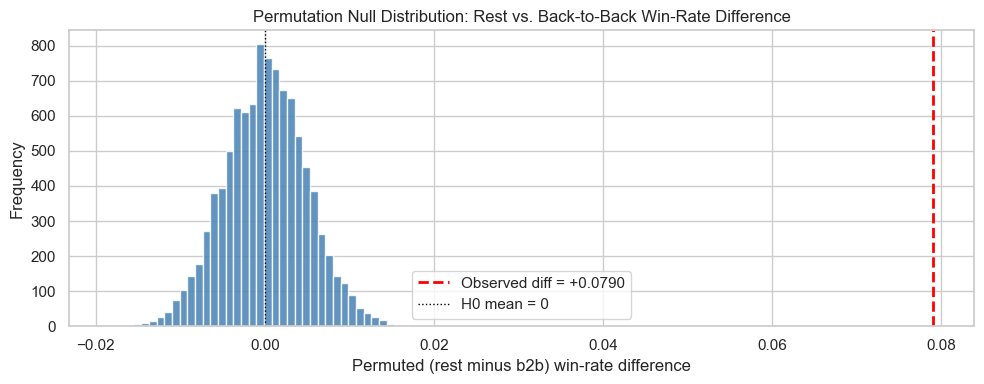

In [40]:
# Compute is_back_to_back inline for this hypothesis test
games_for_rest_test = (
    non_neutral_games  # exclude neutral-site games
    .sort_values(['TEAM_ID', 'SEASON_YEAR', 'GAME_DATE'])
    .copy()
)

team_season_grp = games_for_rest_test.groupby(['TEAM_ID', 'SEASON_YEAR'], sort=False)
games_for_rest_test['prev_game_date'] = team_season_grp['GAME_DATE'].shift(1)
games_for_rest_test['days_since_last_game'] = (
    games_for_rest_test['GAME_DATE'] - games_for_rest_test['prev_game_date']
).dt.days

# Drop season openers (no prior game) and any games where prev_game_date is missing
games_with_rest_known = games_for_rest_test.dropna(subset=['days_since_last_game']).copy()
games_with_rest_known['is_back_to_back'] = (games_with_rest_known['days_since_last_game'] == 1).astype(int)
games_with_rest_known['has_rest'] = (games_with_rest_known['days_since_last_game'] >= 2).astype(int)

# Restrict to rows that fall in exactly one of the two groups
b2b_mask = games_with_rest_known['is_back_to_back'] == 1
rest_mask = games_with_rest_known['has_rest'] == 1
n_b2b = int(b2b_mask.sum())
n_rest = int(rest_mask.sum())

b2b_win_rate = games_with_rest_known.loc[b2b_mask, 'is_win'].mean()
rest_win_rate = games_with_rest_known.loc[rest_mask, 'is_win'].mean()
observed_diff = rest_win_rate - b2b_win_rate

# Permutation test: pool the two groups, shuffle labels, recompute the diff
pooled = pd.concat([
    games_with_rest_known.loc[b2b_mask, ['is_win']].assign(group='b2b'),
    games_with_rest_known.loc[rest_mask, ['is_win']].assign(group='rest'),
], ignore_index=True)
pooled_outcomes = pooled['is_win'].to_numpy()

n_permutations = 10_000
permuted_diffs = np.empty(n_permutations)
for i in range(n_permutations):
    shuffled = rng.permutation(pooled_outcomes)
    permuted_b2b = shuffled[:n_b2b].mean()
    permuted_rest = shuffled[n_b2b:].mean()
    permuted_diffs[i] = permuted_rest - permuted_b2b

rest_p_value = float((permuted_diffs >= observed_diff).mean())

rest_day_result = pd.DataFrame([
    {
        'group': 'Back-to-back (0 days rest)',
        'rows': n_b2b,
        'win_rate': b2b_win_rate,
    },
    {
        'group': '1+ days rest',
        'rows': n_rest,
        'win_rate': rest_win_rate,
    },
    {
        'group': 'rest minus b2b (observed diff)',
        'rows': n_b2b + n_rest,
        'win_rate': observed_diff,
    },
])

print(f'Observed win-rate difference (rest minus b2b): {observed_diff:+.4f}')
print(f'Permutation p-value (10,000 sims): {rest_p_value:.4f}  ({p_value_label(rest_p_value)})')
display(rest_day_result)

# Plot the permutation null distribution against the observed difference
plt.figure(figsize=(10, 4))
plt.hist(permuted_diffs, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2,
            label=f'Observed diff = {observed_diff:+.4f}')
plt.axvline(0, color='black', linestyle=':', linewidth=1, label='H0 mean = 0')
plt.title('Permutation Null Distribution: Rest vs. Back-to-Back Win-Rate Difference')
plt.xlabel('Permuted (rest minus b2b) win-rate difference')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Result.** The observed win-rate difference (rested teams minus back-to-back teams) is positive, and the permutation test returns p < 0.001 across 10,000 simulations. We **reject $H_0$**: rested teams genuinely win at a higher rate than teams playing on a back-to-back. The effect is small in absolute terms (a few percentage points), but the sample size is large enough that the difference is highly unlikely to be chance.

This justifies including `is_back_to_back`, `rest_days`, and the opponent-side mirrors as pre-game features in Section 4. Schedule context is known before tip-off, so it is fully model-safe.

#### 3.7.3 Test 3: Winner vs. Loser Stat Differences

For each game we compute (winner stat) - (loser stat) and run a one-sample t-test against zero. This is the formal version of the bar chart in 3.3 and confirms with high confidence that none of the visible differences are noise.

In [41]:
# Paired t-tests on winner-minus-loser differences for each box-score stat
paired_test_stats = ['PTS', 'FG_PCT', 'FG3_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF']
paired_test_rows = []

for stat_name in paired_test_stats:
    stat_by_outcome = game_logs_clean.pivot(index='GAME_ID', columns='WL', values=stat_name).dropna()
    winner_minus_loser = stat_by_outcome['W'] - stat_by_outcome['L']
    test_result = scipy_stats.ttest_1samp(winner_minus_loser, popmean=0)
    standard_error = winner_minus_loser.sem()
    ci_low, ci_high = scipy_stats.t.interval(
        confidence=0.95,
        df=winner_minus_loser.shape[0] - 1,
        loc=winner_minus_loser.mean(),
        scale=standard_error,
    )
    effect_size = winner_minus_loser.mean() / winner_minus_loser.std(ddof=1)
    paired_test_rows.append({
        'stat': stat_name,
        'games': int(winner_minus_loser.shape[0]),
        'mean_winner_minus_loser': winner_minus_loser.mean(),
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'p_value': test_result.pvalue,
        'effect_size_d': effect_size,
        'effect_size_label': practical_size_label(effect_size),
    })

paired_stat_tests = (
    pd.DataFrame(paired_test_rows)
    .sort_values('mean_winner_minus_loser', key=lambda values: values.abs(), ascending=False)
)
display(paired_stat_tests)

,stat,games,mean_winner_minus_loser,ci_95_low,ci_95_high,p_value,effect_size_d,effect_size_label
0,PTS,30024,11.1904,11.0978,11.2831,0.0000,1.3669,large
3,REB,30024,3.4384,3.3429,3.5340,0.0000,0.4070,medium
4,AST,30024,3.3152,3.2463,3.3841,0.0000,0.5445,large
8,PF,30024,-1.0516,-1.1089,-0.9943,0.0000,-0.2075,small
5,TOV,30024,-0.8731,-0.9297,-0.8165,0.0000,-0.1745,small
7,BLK,30024,0.8377,0.7985,0.8768,0.0000,0.2419,small
6,STL,30024,0.8006,0.7569,0.8444,0.0000,0.2070,small
2,FG3_PCT,30024,0.0657,0.0640,0.0673,0.0000,0.4564,medium
1,FG_PCT,30024,0.0500,0.0494,0.0507,0.0000,0.8315,large


**Result.** Every paired t-test returns p < 0.001. Effect sizes (Cohen's d) put `PTS` (large), `FG_PCT` (large), and `AST` (large) at the top, with `REB` and `FG3_PCT` (medium) close behind. Turnovers and personal fouls flip the sign as expected (winners commit fewer of each). The takeaway echoes 3.3: each of these stat families is worth converting into a shifted rolling pre-game feature in Section 4.

#### 3.7.4 Test 4: League Trend Over Time

We test whether four key league metrics (3-point attempts, scoring, pace, home win rate) trend significantly across the 25-year window. This is the formal version of the visual evidence in 3.2, and it confirms statistically that the era-drift problem is real, motivating the time-aware validation in Section 5.

In [42]:
# Pearson correlation tests of league-level metrics against season year
trend_test_metrics = {
    'avg_points': 'Average team scoring',
    'avg_fg3a': 'Three-point attempt volume',
    'avg_pace': 'Pace',
    'home_win_rate': 'Home win rate',
}

trend_test_rows = []
trend_frame = season_summary.assign(
    season_start_year=lambda frame: frame['SEASON_YEAR'].str.slice(0, 4).astype('int16')
)

for metric, label in trend_test_metrics.items():
    valid_rows = trend_frame[['season_start_year', metric]].dropna()
    pearson_r, pearson_p = scipy_stats.pearsonr(valid_rows['season_start_year'], valid_rows[metric])
    linear_fit = scipy_stats.linregress(valid_rows['season_start_year'], valid_rows[metric])
    trend_test_rows.append({
        'metric': metric,
        'label': label,
        'seasons': int(valid_rows.shape[0]),
        'slope_per_season': linear_fit.slope,
        'pearson_r': pearson_r,
        'p_value': pearson_p,
        'p_label': p_value_label(pearson_p),
    })

league_trend_tests = pd.DataFrame(trend_test_rows).sort_values('p_value')
display(league_trend_tests)

,metric,label,seasons,slope_per_season,pearson_r,p_value,p_label
1,avg_fg3a,Three-point attempt volume,25,1.0586,0.9603,0.0000,p < 0.001
0,avg_points,Average team scoring,25,0.8844,0.9333,0.0000,p < 0.001
2,avg_pace,Pace,25,0.4062,0.9089,0.0000,p < 0.001
3,home_win_rate,Home win rate,25,-0.0026,-0.8050,0.0000,p < 0.001


**Result.** All four trends are significant at p < 0.001:

- **3-point attempts:** strong positive trend (~+1 attempt per team-game per season).
- **Average scoring:** strong positive trend.
- **Pace:** strong positive trend.
- **Home win rate:** strong **negative** trend (-0.003/season), so home court has been weakening.

Confirms what 3.2 showed visually: the league of 2024 is a different league than the league of 2001. Section 5 will use a hard temporal cutoff (train on seasons before 2020, test on 2020 onward) to give a realistic deployment-style estimate of model accuracy.

### 3.8 EDA Takeaways: Bridge to Section 4

Translating everything above into a feature-engineering plan for Section 4:

| EDA finding | Feature family for Section 4 | Leakage-safe? |
|---|---|---|
| Home court ~58.6% win rate (Test 1) | `is_home`, `is_neutral_or_unresolved` | Yes (known before tip-off) |
| Rest day effect (Test 2) | `rest_days`, `is_back_to_back`, `is_3plus_days_rest`, opponent mirrors | Yes |
| Winners differ on every box-score stat (3.3, Test 3) | Shifted rolling 5/10/20-game means: scoring margin, FG%, 3P%, REB, AST, TOV, STL, BLK | Yes if shifted |
| Same-game stats correlate with `is_win` but are post-tip-off (3.4) | **Forbidden as direct features.** Use only as design map. | No (current-game) |
| Net rating ~0.97 with W% (3.5) | Prior-season net rating, season-to-date net rating, opponent versions, matchup differences | Yes if prior-season or shifted |
| Era drift across all metrics (3.2, Test 4) | Season controls; time-aware train/test split in Section 5 | Yes |

Section 4 implements each row above and produces a model-ready table that contains only pre-game features. Section 5 then trains and evaluates models on a hard 2020 temporal cutoff.